In [33]:
import pandas as pd

df = pd.read_csv('train.csv')
df.describe()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [34]:
df.mean()

,0
battery_power,1238.51850
blue,0.49500
clock_speed,1.52225
dual_sim,0.50950
fc,4.30950
four_g,0.52150
int_memory,32.04650
m_dep,0.50175
mobile_wt,140.24900
n_cores,4.52050


In [35]:
print("MEDIAN")
print(df.median())

print("\nMODE")
print(df.mode())

print("\nVARIANCE")
print(df.var())

print("\nSTANDARD DEVIATION")
print(df.std())

print("\nSKEWNESS")
print(df.skew())

print("\nKURTOSIS")
print(df.kurt())

MEDIAN
battery_power    1226.0
blue                0.0
clock_speed         1.5
dual_sim            1.0
fc                  3.0
four_g              1.0
int_memory         32.0
m_dep               0.5
mobile_wt         141.0
n_cores             4.0
pc                 10.0
px_height         564.0
px_width         1247.0
ram              2146.5
sc_h               12.0
sc_w                5.0
talk_time          11.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         1.5
dtype: float64

MODE
   battery_power  blue  clock_speed  dual_sim   fc  four_g  int_memory  m_dep  \
0          618.0   0.0          0.5       1.0  0.0     1.0        27.0    0.1   
1         1589.0   NaN          NaN       NaN  NaN     NaN         NaN    NaN   
2         1872.0   NaN          NaN       NaN  NaN     NaN         NaN    NaN   
3            NaN   NaN          NaN       NaN  NaN     NaN         NaN    NaN   
4            NaN   NaN          NaN       NaN  NaN     NaN     

In [7]:
df['price_range'].value_counts()

NameError: name 'df' is not defined

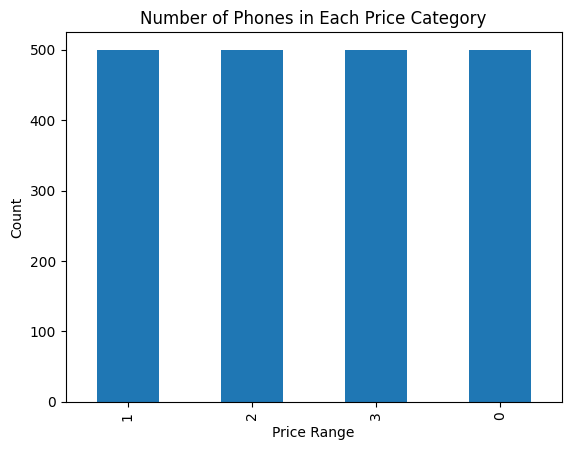

In [36]:
import matplotlib.pyplot as plt

df['price_range'].value_counts().plot(kind='bar')
plt.title('Number of Phones in Each Price Category')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

In [37]:
from scipy import stats

cheap = df[df['price_range'] == 0]['battery_power']

expensive = df[df['price_range'] == 3]['battery_power']

result = stats.ttest_ind(cheap, expensive)

print(result)

TtestResult(statistic=np.float64(-10.07428069471104), pvalue=np.float64(8.451693213396995e-23), df=np.float64(998.0))


A t-test was performed to compare battery power between cheap and expensive phones. The p-value was far below 0.05, meaning the difference is statistically significant and unlikely to be due to random chance. This suggests expensive phones tend to have meaningfully different battery power than cheap phones.

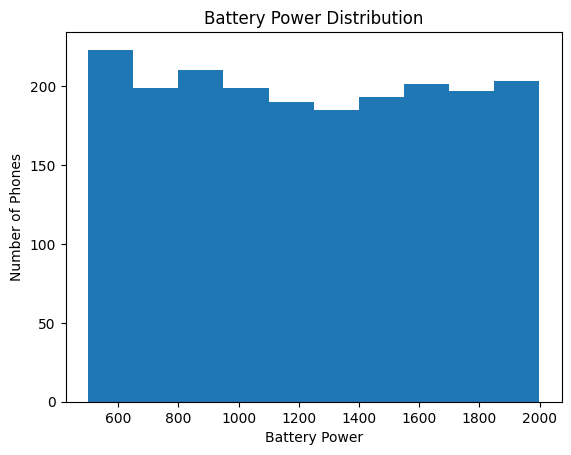

In [38]:
plt.hist(df['battery_power'])
plt.title('Battery Power Distribution')
plt.xlabel('Battery Power')
plt.ylabel('Number of Phones')
plt.show()

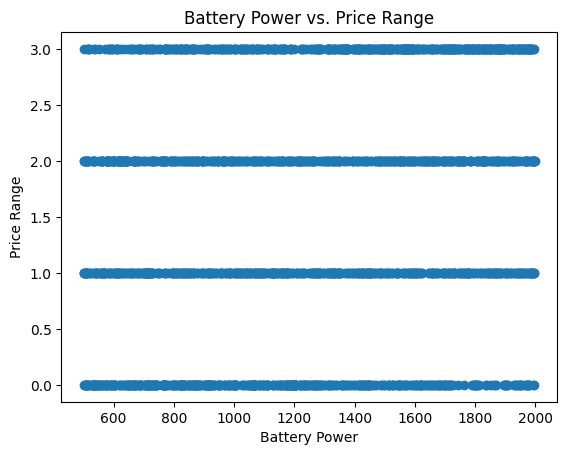

In [17]:
import pandas as pd
df = pd.read_csv('train.csv')
plt.scatter(df['battery_power'], df['price_range'])
plt.title('Battery Power vs. Price Range')
plt.xlabel('Battery Power')
plt.ylabel('Price Range')
plt.show()

Battery power has some spread across all price categories, so it does not look like a clean predictor by itself.

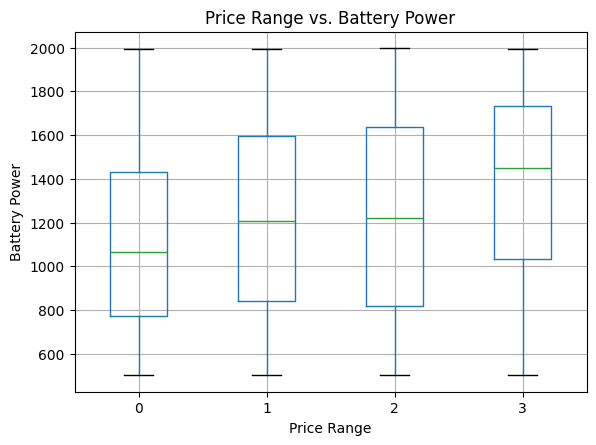

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('train.csv')
df.boxplot(column='battery_power', by='price_range')
plt.suptitle('')
plt.title('Price Range vs. Battery Power')
plt.xlabel('Price Range')
plt.ylabel('Battery Power')
plt.show()


Battery power generally increases with higher price categories. However, the median battery power for price ranges 1 and 2 shows only a small difference, while price range 3 demonstrates a noticeably higher median battery capacity. This suggests battery power may contribute to price classification, but may not strongly distinguish mid-tier devices.

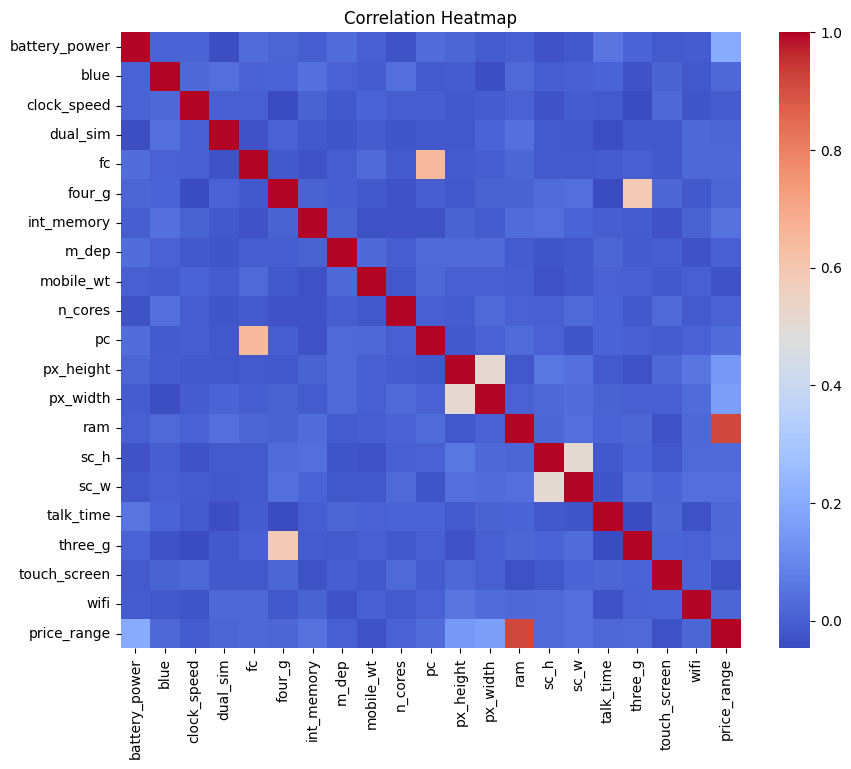

np.float64(0.9170457362649902)

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
correlation_matrix.loc['price_range', 'ram']

RAM is one of the strongest predictors of phone price range in this dataset. As RAM increases, price category tends to increase significantly.

In [30]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


The dataset contains no missing values across any features, so no imputation or row removal was required during preprocessing.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

All dataset features are already numeric (int64/float64), so no categorical encoding or transformation was necessary.

In [32]:
from scipy import stats

group0 = df[df['price_range'] == 0]['battery_power']
group1 = df[df['price_range'] == 1]['battery_power']
group2 = df[df['price_range'] == 2]['battery_power']
group3 = df[df['price_range'] == 3]['battery_power']

anova_result = stats.f_oneway(group0, group1, group2, group3)

print(anova_result)

F_onewayResult(statistic=np.float64(31.598157539897333), pvalue=np.float64(5.948688277085545e-20))


ANOVA was used to compare battery power across all four price categories. A p-value below 0.05 indicates statistically significant differences between at least some of the groups.

The t-test and ANOVA showed statistically significant differences in battery power between price categories. Visualizations showed that battery power generally increases with price, although there is overlap between group

Correlation analysis showed RAM had the strongest relationship with price range (0.917), making it the most important predictor in this dataset.